In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna
from sklearn.metrics import accuracy_score

In [267]:
df = pd.read_csv(r"C:\Users\shiva\Downloads\archive (11)\Hotel Reservations.csv")

In [269]:
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [271]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [273]:
df.duplicated().sum()

np.int64(0)

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [277]:
df.drop(["Booking_ID","arrival_date"],axis=1,inplace = True)

In [279]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,Online,0,0,0,167.80,1,Not_Canceled
36271,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,Online,0,0,0,90.95,2,Canceled
36272,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,Online,0,0,0,98.39,2,Not_Canceled
36273,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,Online,0,0,0,94.50,0,Canceled


In [281]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

In [283]:
df["booking_status"] = df["booking_status"].map({"Not_Canceled":0,"Canceled":1})

In [285]:
df["booking_status"]

0        0
1        0
2        1
3        1
4        1
        ..
36270    0
36271    1
36272    0
36273    1
36274    0
Name: booking_status, Length: 36275, dtype: int64

In [287]:
x = df.drop("booking_status",axis=1)
y = df["booking_status"]

In [289]:
from sklearn.model_selection import train_test_split

In [291]:
x_train_full,x_test,y_train_full,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [293]:
x_train,x_val,y_train,y_val = train_test_split(x_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [295]:
num_cols = x.select_dtypes(exclude = "object").columns
cat_cols = x.select_dtypes(include = "object").columns

In [297]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [299]:
preprocessor = ColumnTransformer([("Scaling", StandardScaler(), num_cols),
                   ("Encoder", OneHotEncoder(drop="first",handle_unknown="ignore"),cat_cols)],
                  remainder="passthrough")

In [301]:
x_train_trans = preprocessor.fit_transform(x_train)
x_val_trans = preprocessor.transform(x_val)
x_test_trans = preprocessor.transform(x_test)

In [303]:
x_train_trans

array([[-3.53904072,  4.75456388,  1.368037  , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.30014293, -0.26371013,  1.368037  , ...,  0.        ,
         0.        ,  1.        ],
       [-1.61944889, -0.26371013,  0.21729979, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.30014293, -0.26371013, -0.93343742, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.30014293,  2.24542688,  0.21729979, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.30014293, -0.26371013, -0.93343742, ...,  0.        ,
         0.        ,  1.        ]], shape=(23216, 26))

In [305]:
x_train_trans = pd.DataFrame(x_train_trans)
x_train_trans

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,-3.539041,4.754564,1.368037,1.283809,-0.179541,1.751619,0.466409,-0.137172,-0.162741,-0.06207,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.300143,-0.263710,1.368037,-0.850602,-0.179541,1.391704,-2.144042,-0.137172,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-1.619449,-0.263710,0.217300,-1.562072,-0.179541,-0.756179,0.466409,0.513341,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2.219735,-0.263710,1.368037,-0.139131,-0.179541,-0.953552,0.466409,1.489111,-0.162741,-0.06207,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.300143,-0.263710,-0.933437,-0.139131,-0.179541,-0.860670,0.466409,-0.787685,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23211,0.300143,2.245427,-0.933437,-0.850602,-0.179541,-0.547196,0.466409,0.188085,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23212,0.300143,-0.263710,-0.933437,0.572339,-0.179541,1.008568,0.466409,0.838598,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
23213,0.300143,-0.263710,-0.933437,-0.850602,-0.179541,-0.512365,0.466409,0.838598,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23214,0.300143,2.245427,0.217300,1.283809,-0.179541,-0.407873,0.466409,-1.763455,-0.162741,-0.06207,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [307]:
from keras.models import Sequential
from keras.layers import Input,Dense

In [309]:
model = Sequential([Input(shape=(x_train_trans.shape[1],)),
                    Dense(64,activation="relu"),
                    Dense(32,activation="relu"),
                    Dense(1,activation="sigmoid")])

In [311]:
model.compile(optimizer="Adam",loss = "binary_crossentropy", metrics = ["accuracy"])

In [313]:
from keras.callbacks import EarlyStopping
early = EarlyStopping(monitor = "val_loss",patience = 5 , restore_best_weights=True)

In [235]:
model.fit(x_train_trans,y_train,
          epochs = 50,
          validation_data=(x_val_trans,y_val),
          batch_size=256,
          callbacks=[early],
          verbose = 2)

Epoch 1/50
91/91 - 4s - 48ms/step - accuracy: 0.7240 - loss: 0.5328 - val_accuracy: 0.8019 - val_loss: 0.4315
Epoch 2/50
91/91 - 1s - 7ms/step - accuracy: 0.8121 - loss: 0.4149 - val_accuracy: 0.8169 - val_loss: 0.4030
Epoch 3/50
91/91 - 1s - 8ms/step - accuracy: 0.8197 - loss: 0.3970 - val_accuracy: 0.8210 - val_loss: 0.3950
Epoch 4/50
91/91 - 1s - 7ms/step - accuracy: 0.8233 - loss: 0.3880 - val_accuracy: 0.8260 - val_loss: 0.3881
Epoch 5/50
91/91 - 1s - 6ms/step - accuracy: 0.8269 - loss: 0.3812 - val_accuracy: 0.8305 - val_loss: 0.3864
Epoch 6/50
91/91 - 1s - 6ms/step - accuracy: 0.8295 - loss: 0.3761 - val_accuracy: 0.8268 - val_loss: 0.3833
Epoch 7/50
91/91 - 1s - 6ms/step - accuracy: 0.8333 - loss: 0.3711 - val_accuracy: 0.8277 - val_loss: 0.3792
Epoch 8/50
91/91 - 1s - 6ms/step - accuracy: 0.8352 - loss: 0.3664 - val_accuracy: 0.8330 - val_loss: 0.3763
Epoch 9/50
91/91 - 1s - 6ms/step - accuracy: 0.8375 - loss: 0.3625 - val_accuracy: 0.8320 - val_loss: 0.3747
Epoch 10/50
91/91 

In [315]:
y_pred = np.where(model.predict(x_test_trans)>0.5,1,0)

227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [317]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.5867677463818056

In [319]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(x_train_trans.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        x_train_trans, y_train,
        epochs=30, batch_size=batch_size1,
        validation_data=(x_val_trans, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [321]:
study = optuna.create_study(direction = "maximize", sampler = optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)

[I 2026-06-29 15:38:01,526] A new study created in memory with name: no-name-b8fdc261-1bcd-4e2d-9357-9c5cfad852d3
Best trial: 0. Best value: 0.632492:  20%|██        | 1/5 [00:13<00:54, 13.57s/it]

[I 2026-06-29 15:38:15,108] Trial 0 finished with value: 0.6324921250343323 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.6324921250343323.


Best trial: 1. Best value: 0.709253:  40%|████      | 2/5 [00:35<00:55, 18.35s/it]

[I 2026-06-29 15:38:36,795] Trial 1 finished with value: 0.7092534303665161 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.7092534303665161.


Best trial: 1. Best value: 0.709253:  60%|██████    | 3/5 [01:05<00:47, 23.81s/it]

[I 2026-06-29 15:39:07,101] Trial 2 finished with value: 0.6929547786712646 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 64, 'units0': 78, 'dropout0': 0.4438277186036015, 'reg0': 0.00124905731421375, 'units1': 48, 'dropout1': 0.15295758239442775, 'reg1': 0.0028857135238802138}. Best is trial 1 with value: 0.7092534303665161.


Best trial: 3. Best value: 0.733438:  80%|████████  | 4/5 [01:11<00:16, 16.61s/it]

[I 2026-06-29 15:39:12,690] Trial 3 finished with value: 0.7334384918212891 and parameters: {'learning_rate': 0.00019025203500883987, 'n_layers': 2, 'optimizer': 'SGD', 'activation': 'relu', 'batch_size': 256, 'units0': 73, 'dropout0': 0.23032323416126815, 'reg0': 0.00391072473921031, 'units1': 70, 'dropout1': 0.08398753671647846, 'reg1': 3.44936712080066e-05}. Best is trial 3 with value: 0.7334384918212891.


Best trial: 4. Best value: 0.753943: 100%|██████████| 5/5 [01:21<00:00, 16.32s/it]

[I 2026-06-29 15:39:23,127] Trial 4 finished with value: 0.7539432048797607 and parameters: {'learning_rate': 0.005009680824617574, 'n_layers': 2, 'optimizer': 'SGD', 'activation': 'relu', 'batch_size': 64, 'units0': 58, 'dropout0': 0.2555683582705914, 'reg0': 0.0003865733636663784, 'units1': 54, 'dropout1': 0.4659387787965033, 'reg1': 5.4919655207867996e-05}. Best is trial 4 with value: 0.7539432048797607.


In [323]:
study.best_params

{'learning_rate': 0.005009680824617574,
 'n_layers': 2,
 'optimizer': 'SGD',
 'activation': 'relu',
 'batch_size': 64,
 'units0': 58,
 'dropout0': 0.2555683582705914,
 'reg0': 0.0003865733636663784,
 'units1': 54,
 'dropout1': 0.4659387787965033,
 'reg1': 5.4919655207867996e-05}

In [325]:
model  = Sequential()

# Input Layer 
model.add(Input(shape=(x_train_trans.shape[1],)))

# 1st hidden Layer 

model.add(Dense(58,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1= 0.0003865733636663784,l2 =  0.0003865733636663784)))
model.add(BatchNormalization())
model.add(Dropout(0.2555683582705914))

#2nd hiddeh layer
model.add(Dense(54,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=5.4919655207867996e-05,l2 = 5.4919655207867996e-05)))
model.add(BatchNormalization())
model.add(Dropout(0.4659387787965033))


# Output layer 
model.add(Dense(1,activation='sigmoid',kernel_initializer="glorot_uniform"))

In [327]:
model.compile(optimizer=SGD(learning_rate=0.005009680824617574), loss='binary_crossentropy',
                  metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [329]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [331]:
history = model.fit(
        x_train_trans, y_train,
        epochs=30, batch_size=64,
        validation_data=(x_val_trans, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
history

In [332]:
y_pred=np.where(model.predict(x_test_trans)>0.5,1,0)

227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [333]:
accuracy_score(y_pred,y_test)

0.7778084079944866

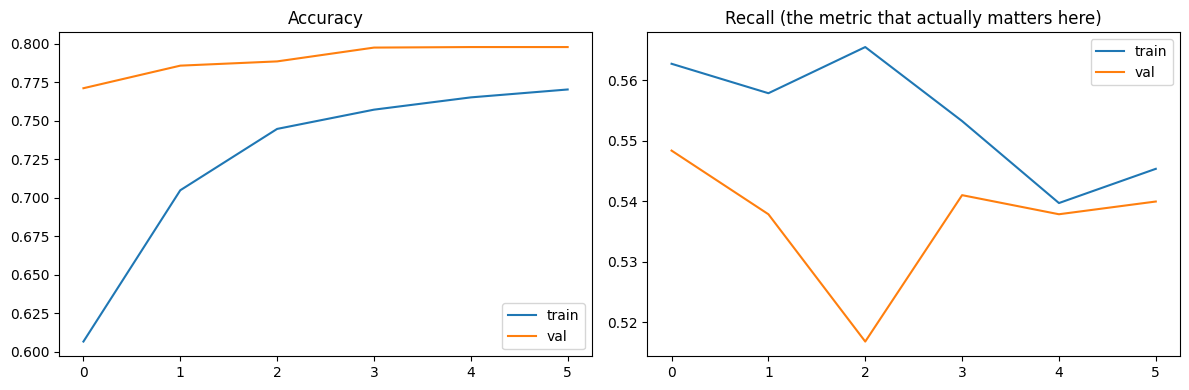

In [334]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['recall'], label='train')
axes[1].plot(history.history['val_recall'], label='val')
axes[1].set_title('Recall (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [335]:
# Training accuracy
y_pred_train = np.where(model.predict(x_train_trans) > 0.5, 1, 0)
train_acc = accuracy_score(y_train, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(x_val_trans) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(x_test_trans) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

726/726 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
182/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train Accuracy      : 0.7692
Validation Accuracy : 0.7710
Test Accuracy       : 0.7778


In [343]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84      4878
           1       0.70      0.57      0.63      2377

    accuracy                           0.78      7255
   macro avg       0.75      0.72      0.73      7255
weighted avg       0.77      0.78      0.77      7255



In [345]:
import pickle

with open('Preprocessor1.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model1.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras
